In [42]:
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
df = pd.read_csv('../data/processed/final_dataset.csv')

In [44]:
df.shape

(2208, 19)

In [45]:
df.dtypes

temperature_2m         float64
wind_speed_10m         float64
wind_direction_10m       int64
cloud_cover              int64
shortwave_radiation    float64
precipitation          float64
Price (EUR/MWhe)       float64
P                      float64
Gb(i)                  float64
Gd(i)                  float64
Gr(i)                  float64
H_sun                  float64
T2m                    float64
WS10m                  float64
Datetime (UTC)          object
hour                     int64
day_of_week              int64
month                    int64
is_weekend               int64
dtype: object

In [46]:
df.describe()

,temperature_2m,wind_speed_10m,wind_direction_10m,cloud_cover,shortwave_radiation,precipitation,Price (EUR/MWhe),P,Gb(i),Gd(i),Gr(i),H_sun,T2m,WS10m,hour,day_of_week,month,is_weekend
count,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000
mean,17.400951,8.309194,211.824728,67.968750,185.511775,0.109103,90.986866,93.037998,65.209348,60.908718,2.534706,18.044072,18.434248,2.517382,11.500000,3.021739,7.989130,0.293478
std,4.753936,5.325348,84.323522,38.767912,230.363094,1.085637,44.727773,113.548693,94.806137,70.602317,3.119314,20.012931,4.391165,1.470591,6.923755,2.000335,0.814387,0.455459
min,5.500000,0.400000,1.000000,0.000000,0.000000,0.000000,-316.400000,0.000000,0.000000,0.000000,0.000000,-4.210000,7.840000,0.000000,0.000000,0.000000,7.000000,0.000000
25%,14.000000,4.200000,150.000000,37.000000,0.000000,0.000000,75.767500,0.000000,0.000000,0.000000,0.000000,0.000000,15.230000,1.380000,5.750000,1.000000,7.000000,0.000000
50%,16.900000,6.900000,225.000000,91.000000,65.000000,0.000000,94.980000,37.115000,7.765000,42.895000,0.850000,9.660000,17.920000,2.210000,11.500000,3.000000,8.000000,0.000000
75%,20.400000,11.600000,270.000000,100.000000,349.000000,0.000000,112.177500,171.385000,106.347500,102.567500,4.762500,35.662500,21.282500,3.450000,17.250000,5.000000,9.000000,1.000000
max,32.900000,28.400000,360.000000,100.000000,894.000000,42.600000,363.690000,450.380000,439.010000,328.180000,11.720000,61.910000,33.240000,7.790000,23.000000,6.000000,9.000000,1.000000


In [47]:
df.isna().sum()

temperature_2m         0
wind_speed_10m         0
wind_direction_10m     0
cloud_cover            0
shortwave_radiation    0
precipitation          0
Price (EUR/MWhe)       0
P                      0
Gb(i)                  0
Gd(i)                  0
Gr(i)                  0
H_sun                  0
T2m                    0
WS10m                  0
Datetime (UTC)         0
hour                   0
day_of_week            0
month                  0
is_weekend             0
dtype: int64

In [48]:
df.duplicated().sum()

0

In [49]:
df['Price (EUR/MWhe)'].describe()

count    2208.000000
mean       90.986866
std        44.727773
min      -316.400000
25%        75.767500
50%        94.980000
75%       112.177500
max       363.690000
Name: Price (EUR/MWhe), dtype: float64

In [50]:
(df['Price (EUR/MWhe)'] < 0).sum()

76

In [51]:
(df['Price (EUR/MWhe)'] > 300).sum()

3

In [52]:
night = df[df['hour'].isin([0, 1, 2, 3, 4, 22, 23])]

In [53]:
night.sum()

temperature_2m                                                    9088.2
wind_speed_10m                                                    3757.7
wind_direction_10m                                                133863
cloud_cover                                                        43723
shortwave_radiation                                                193.0
precipitation                                                      106.4
Price (EUR/MWhe)                                                55756.55
P                                                                2629.08
Gb(i)                                                            2334.93
Gd(i)                                                            1829.34
Gr(i)                                                              35.69
H_sun                                                             293.62
T2m                                                              9877.81
WS10m                                              

In [54]:
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])
df = df.set_index('Datetime (UTC)')

In [55]:
df.corr()[['P', 'Price (EUR/MWhe)']].sort_values('P', ascending=False)

,P,Price (EUR/MWhe)
P,1.000000,-0.415655
Gr(i),0.924839,-0.402692
H_sun,0.909639,-0.450668
Gb(i),0.904724,-0.322793
Gd(i),0.836074,-0.391318
shortwave_radiation,0.834610,-0.352350
temperature_2m,0.460226,-0.045493
T2m,0.446478,-0.016570
wind_speed_10m,0.407646,-0.464170
WS10m,0.317196,-0.509794


In [56]:
df.index.to_series().diff().value_counts()

Datetime (UTC)
0 days 01:00:00    2207
Name: count, dtype: int64

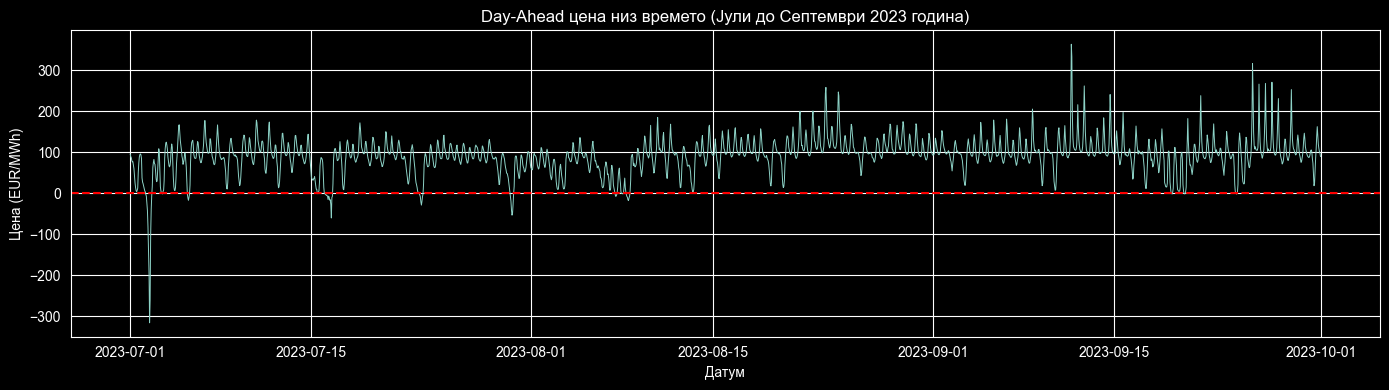

In [57]:
plt.figure(figsize=(14,4))
plt.plot(df.index, df['Price (EUR/MWhe)'], linewidth=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Day-Ahead цена низ времето (Јули до Септември 2023 година)')
plt.xlabel('Датум')
plt.ylabel('Цена (EUR/MWh)')
plt.tight_layout()
plt.show()

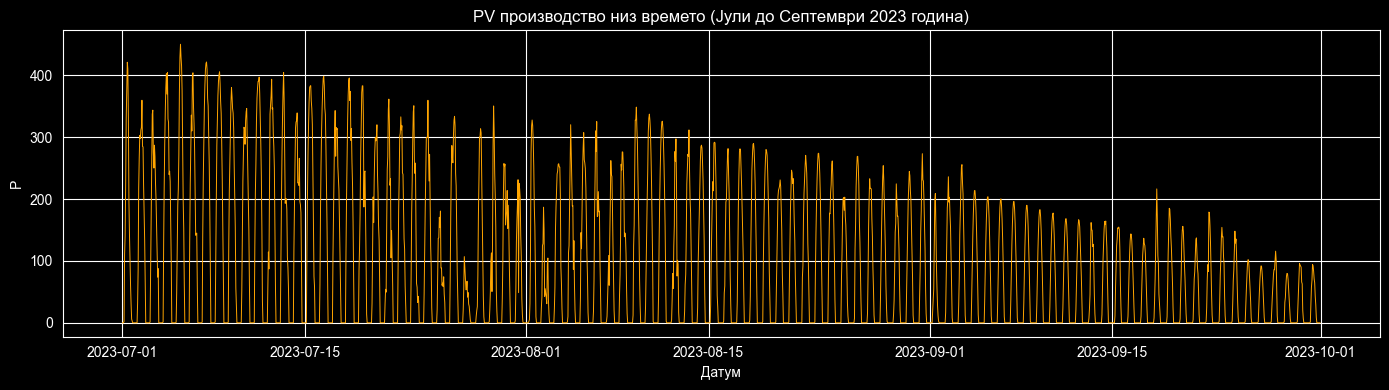

In [58]:
plt.figure(figsize=(14,4))
plt.plot(df.index, df['P'], linewidth=0.7, color='orange')
plt.title('PV производство низ времето (Јули до Септември 2023 година)')
plt.xlabel('Датум')
plt.ylabel('P')
plt.tight_layout()
plt.show()

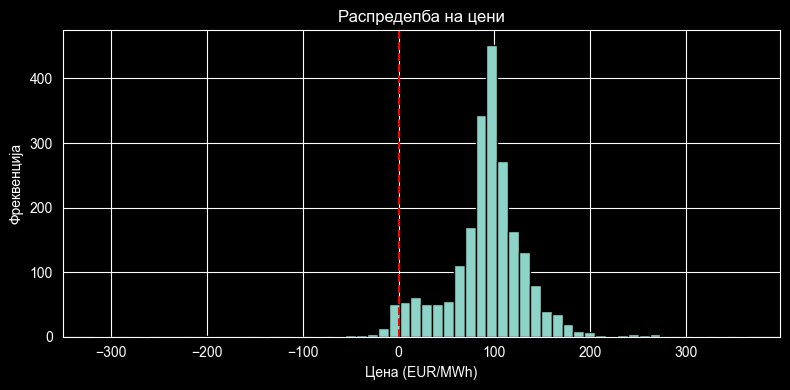

In [59]:
plt.figure(figsize=(8,4))
plt.hist(df['Price (EUR/MWhe)'], bins=60, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title('Распределба на цени')
plt.xlabel('Цена (EUR/MWh)')
plt.ylabel('Фреквенција')
plt.tight_layout()
plt.show()

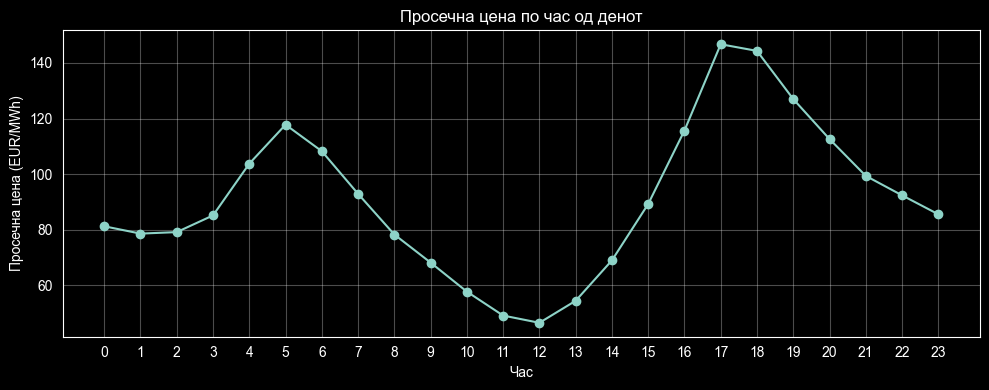

In [60]:
hourly_price = df.groupby('hour')['Price (EUR/MWhe)'].mean()

plt.figure(figsize=(10,4))
plt.plot(hourly_price.index, hourly_price.values, marker='o')
plt.title('Просечна цена по час од денот')
plt.xlabel('Час')
plt.ylabel('Просечна цена (EUR/MWh)')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

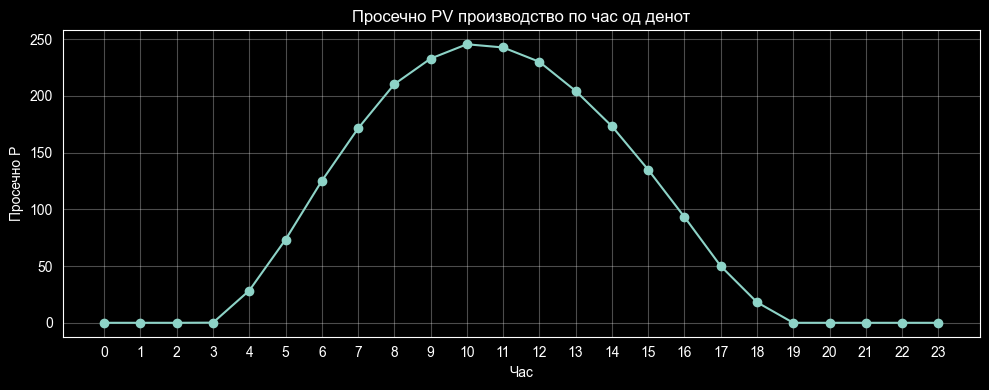

In [61]:
hourly_production = df.groupby('hour')['P'].mean()

plt.figure(figsize=(10,4))
plt.plot(hourly_production.index, hourly_production.values, marker='o')
plt.title('Просечнo PV производство по час од денот')
plt.xlabel('Час')
plt.ylabel('Просечно P')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

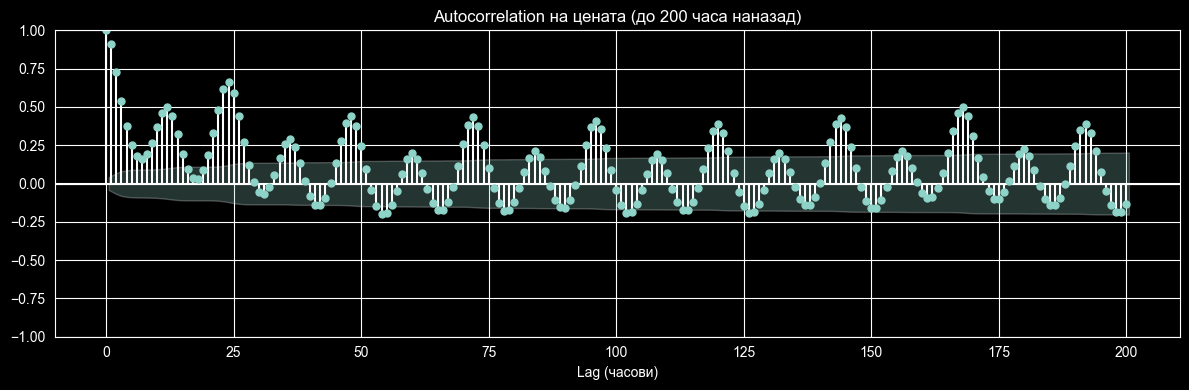

In [62]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12,4))
plot_acf(df['Price (EUR/MWhe)'], lags=200, ax=ax)
plt.title('Аutocorrelation на цената (до 200 часа наназад)')
plt.xlabel('Lag (часови)')
plt.tight_layout()
plt.show()

In [63]:
negative_price_hours = df[df['Price (EUR/MWhe)'] < 0]

print('Просечно Р за часови со НЕГАТИВНА цена: ', negative_price_hours['P'].mean())
print('Просечно Р за сите часови: ', df['P'].mean())
print('Просечен час од денот кога цената е негативна: ', negative_price_hours['hour'].mean())

Просечно Р за часови со НЕГАТИВНА цена:  224.60263157894735
Просечно Р за сите часови:  93.03799818840581
Просечен час од денот кога цената е негативна:  10.210526315789474


In [64]:
weekday_avg = df[df['is_weekend'] == 0]['Price (EUR/MWhe)'].mean()
weekend_avg = df[df['is_weekend'] == 1]['Price (EUR/MWhe)'].mean()

print(f"Просечна цена во работен ден: {weekday_avg:.2f} EUR/MWh")
print(f"Просечна цена за викенд: {weekend_avg:.2f} EUR/MWh")
print(f"Разлика: {weekday_avg - weekend_avg:.2f} EUR/MWh")

Просечна цена во работен ден: 99.64 EUR/MWh
Просечна цена за викенд: 70.15 EUR/MWh
Разлика: 29.49 EUR/MWh


In [65]:
night = df[df['hour'].isin([0, 1, 2, 22, 23])]
print("Максимално P ноќе:", night['P'].max())
print("Просечно P ноќе:", night['P'].mean())

Максимално P ноќе: 0.0
Просечно P ноќе: 0.0


In [66]:
print(hourly_production)

hour
0       0.000000
1       0.000000
2       0.000000
3       0.136957
4      28.440000
5      73.334783
6     125.048696
7     171.270978
8     210.258370
9     232.789891
10    245.420000
11    242.598152
12    229.939130
13    204.281739
14    173.184891
15    134.879565
16     93.238261
17     49.973370
18     18.117174
19      0.000000
20      0.000000
21      0.000000
22      0.000000
23      0.000000
Name: P, dtype: float64
